In [155]:
import os
import pandas as pd
import numpy as np

%load_ext autoreload
%autoreload 2

%matplotlib inline

%config InlineBackend.figure_format = 'svg' # other available formats are: 'retina', 'png', 'jpeg', 'pdf'

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [156]:
import umap
import plotly.express as px
import matplotlib.pyplot as plt

## GENERAL

def calculate_embedding(
    data, 
    n_neighbors=15, 
    min_dist=0.1, 
    n_components=2,
    metric='euclidean', 
    ): 
    
    # construct model
    reducer = umap.UMAP(
        random_state=42, 
        n_components=n_components, 
        n_neighbors=n_neighbors,
        metric=metric)
    
    # train model 
    reducer.fit(data)
    
    # to access the resulting transform, we inspect `embedding_` attribute
    # or call transform on the original data
    embedding = reducer.transform(data)
#     embedding = reducer.fit_transform(data);

    return embedding
    
def plot_umap(embedding, target=None, title=''):
    # now plot the resulting embedding, coloring the data points by the class that they belong to
    n_components = embedding.shape[1]
    fig = plt.figure()
    if n_components==1:
        fig.add_subplot(111)
        plt.scatter(embedding[:, 0], range(len(embedding)), c=target, cmap='Spectral', s=5)
    if n_components==2:
        fig.add_subplot(111)
        plt.scatter(embedding[:, 0], embedding[:, 1], c=target, cmap='Spectral', s=5)
    if n_components==3:
        fig.add_subplot(111, projection='3d')
        plt.scatter(embedding[:, 0], embedding[:, 1], c=target, cmap='Spectral', s=5)
    
    plt.title(title, fontsize=18)
    plt.gca().set_aspect('equal', 'datalim')
    if target is not None:
        plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
    
    plt.show()
        
def plot_umap_3d(dataframe, hue=None):
    fig = px.scatter_3d(dataframe, x='x', y='y', z='z', color=hue)
    fig.show()

## Example - MNIST Data

https://umap-learn.readthedocs.io/en/latest/basic_usage.html

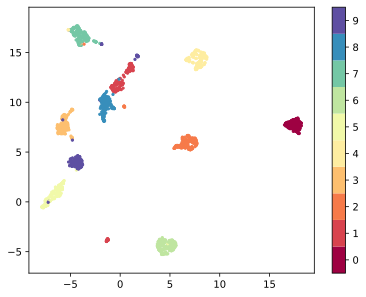

In [277]:
import pandas as pd
from sklearn.datasets import load_digits

# get digits data
digits = load_digits()

# make dataframe
digits_df = pd.DataFrame(digits.data[:,1:11])
digits_df['digit'] = pd.Series(digits.target).map(lambda x: 'Digit {}'.format(x))

# calculate embedding with 2 n_components
embedding_2_comp = calculate_embedding(data=digits.data, n_components=2)

# visualize embedding (static display)
plot_umap(embedding_2_comp, target=digits.target) 

# calculate embedding with 3 n_components
embedding_3_comp = calculate_embedding(data=digits.data, n_components=3)

# visualize 3d embedding (interactive display)
df_embedding = pd.DataFrame(embedding_3_comp, columns=['x', 'y', 'z'])
df_target = pd.DataFrame(digits.target, columns=['color'])
dataframe = pd.concat([df_embedding, df_target], axis=1)

plot_umap_3d(dataframe, hue='color')

## HBN

In [190]:
from hbn.data import make_dataset
from hbn.constants import Defaults

# make train/test splits for participants
make_dataset.make_train_test_splits(column='DX_01', out_dir=Defaults.MODEL_SPEC_DIR)


writing train and test participants to file for ADHD-Combined_Type
writing train and test participants to file for ADHD-Hyperactive_Impulsive_Type
writing train and test participants to file for ADHD-Inattentive_Type
writing train and test participants to file for Acute_Stress_Disorder
writing train and test participants to file for Adjustment_Disorders
writing train and test participants to file for Agoraphobia
could not write out train and test participants for Alcohol_Use_Disorder -- likely too few samples
writing train and test participants to file for Autism_Spectrum_Disorder
could not write out train and test participants for Avoidant_Restrictive_Food_Intake_Disorder -- likely too few samples
writing train and test participants to file for Bipolar_I_Disorder
writing train and test participants to file for Bipolar_II_Disorder
writing train and test participants to file for Borderline_Intellectual_Functioning
could not write out train and test participants for Bulimia_Nervosa -- li

In [357]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from hbn.features import build_features 

# HBN Functions

def get_data(phenotype_widget, participant_widget, target_col='DX_01'):

    # get features
    features = build_features.get_features(
                assessment=phenotype_widget.children[0].value,
                domains=[phenotype_widget.children[1].value],
                measures=list(phenotype_widget.children[2].value),
                min_num_participants=2000,
                incl_data_type=None
                );

    # preprocess features
    features_preprocessed = build_features.column_transform(
                        dataframe=features,
                        cols_to_ignore=['Identifiers'],
                        clf_info={"numeric": [[
                                        "sklearn.impute",
                                        "SimpleImputer",
                                        {"strategy": "mean"}],
#                                         [
#                                         "sklearn.preprocessing",
#                                         "StandardScaler",
#                                         {}
#                                     ]
                                ]
                                 }
                                )


    # get targets
    targets = build_features.get_targets(target_info = {
                                        "assessment": "Clinical Measures",
                                        "domain": None,
                                        "measure": "Clinical Diagnosis Demographics",
                                        "target_column": target_col,
                                        "transform": None,
                                        "outname": target_col
                                        })

    # get participant ids
    participants = make_dataset.get_participants(
                                split=participant_widget.children[0].value, 
                                disorders=list(participant_widget.children[2].value)
                                )
    
    features_target = features_preprocessed.merge(
                                targets, on='Identifiers').merge(
                                participants, on='Identifiers').drop(
                                'Identifiers', axis=1)
    # get feature names
    feature_names = [col for col in features_target.columns if target_col not in col]

    return features_target[feature_names], features_target[target_col]


def visualize_embedding(features, target):
    """visualize embedding
    
    Args: 
        features (pd dataframe): shape (n_rows, n_cols) 
        target (pd dataframe): shape (n_rows,1) same n_rows as `features`
    """
    # calculate and visualize embedding (3d display)
    embedding_3_comp = calculate_embedding(data=features, n_components=3)
    df_embedding = pd.DataFrame(embedding_3_comp, columns=['x', 'y', 'z'])
    dataframe = pd.concat([df_embedding, target], axis=1)

    plot_umap_3d(dataframe, hue=target)

def get_phenotype_inputs(assessment=['Child Measures', 'Parent Measures', 'Teacher Measures']):
    w1 = widgets.Dropdown(options=assessment)
    w2 = widgets.Dropdown(options=[])
    w3 = widgets.SelectMultiple(
                options=[],
                value=[],
                rows=12,
                description='Measure:',
                disabled=False)
    
    def update_domain_options(change):
        w2.options = build_features.get_domains(change.new)[change.new]
    w1.observe(update_domain_options, 'value')
    def update_measure_options(change):
        w3.options = build_features.get_measures(assessment=w1.value, domain=change.new)[change.new]
    w2.observe(update_measure_options, 'value')
    return widgets.VBox([w1, w2, w3]) 

phenotype_widget = get_phenotype_inputs()
display(phenotype_widget)

def get_participant_inputs(participants=['train', 'test']):
    w1 = widgets.Dropdown(options=participants)
    w2 = widgets.Dropdown(options=[])
    w3 = widgets.SelectMultiple(
                options=[],
                value=[],
                rows=15,
                description='Disorder:',
                disabled=False)
    
    def update_domain_options(change):
        w2.options = make_dataset.get_disorder_categories()
    w1.observe(update_domain_options, 'value')
    def update_measure_options(change):
        w3.options =make_dataset.get_disorder(column='DX_01', category=change.new)
    w2.observe(update_measure_options, 'value')
    return widgets.VBox([w1, w2, w3]) 


participant_widget = get_participant_inputs()
display(participant_widget)

## Visualize embeddings for HBN data

In [373]:
# get data
features, target = get_data(phenotype_widget, participant_widget)

reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Parent_Measures/Demographic_Questionnaire_Measures/Demographics.csv into dataframe
reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Parent_Measures/Demographic_Questionnaire_Measures/Financial_Support_Questionnaire.csv into dataframe
reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Parent_Measures/Demographic_Questionnaire_Measures/Barratt_Simplified_Measure_of_Social_Status.csv into dataframe
reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Parent_Measures/Demographic_Questionnaire_Measures/Child_Behavior_Checklist.csv into dataframe
reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Parent_Measures/Demographic_Questionnaire_Measures/Mood_and_Feelings_Questionnaire.csv into dataframe
reading /Users/maedbhking/Documents/healthy_brain_network/data/raw/phenotype/Parent_Measures/Demographic_Questionnaire_

In [374]:
# visualize embedding
visualize_embedding(features, target=target)